In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv(r"C:/Users/natar/OneDrive/Desktop/mltp/mpg.csv")
print(df.head())
print(df.info())
print(df.describe())


    mpg  cylinders  displacement horsepower  weight  acceleration  model_year  \
0  18.0          8         307.0        130    3504          12.0          70   
1  15.0          8         350.0        165    3693          11.5          70   
2  18.0          8         318.0        150    3436          11.0          70   
3  16.0          8         304.0        150    3433          12.0          70   
4  17.0          8         302.0        140    3449          10.5          70   

   origin                       name  
0       1  chevrolet chevelle malibu  
1       1          buick skylark 320  
2       1         plymouth satellite  
3       1              amc rebel sst  
4       1                ford torino  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2 

In [2]:
df.drop_duplicates()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86,2790,15.6,82,1,ford mustang gl
394,44.0,4,97.0,52,2130,24.6,82,2,vw pickup
395,32.0,4,135.0,84,2295,11.6,82,1,dodge rampage
396,28.0,4,120.0,79,2625,18.6,82,1,ford ranger


In [3]:
print(df['mpg'].isnull().sum())
print(df['horsepower'].isnull().sum())

0
0


In [4]:
# Convert horsepower to numeric
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')

In [5]:
# Handle missing values
df['horsepower'] = df['horsepower'].fillna(df['horsepower'].median())

In [6]:
Q1 = df['horsepower'].quantile(0.25)
Q3 = df['horsepower'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['horsepower'] < lower_bound) | (df['horsepower'] > upper_bound)]

print("Number of outliers:", outliers.shape[0])

Number of outliers: 11


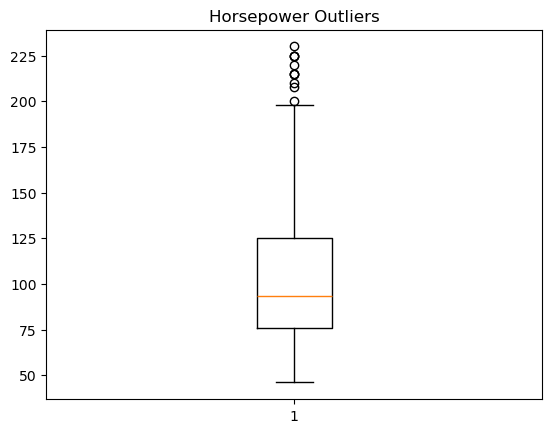

In [7]:
import matplotlib.pyplot as plt

plt.figure()
plt.boxplot(df['horsepower'])
plt.title("Horsepower Outliers")
plt.show()


In [8]:
X = df[['horsepower']]   
Y = df['mpg']

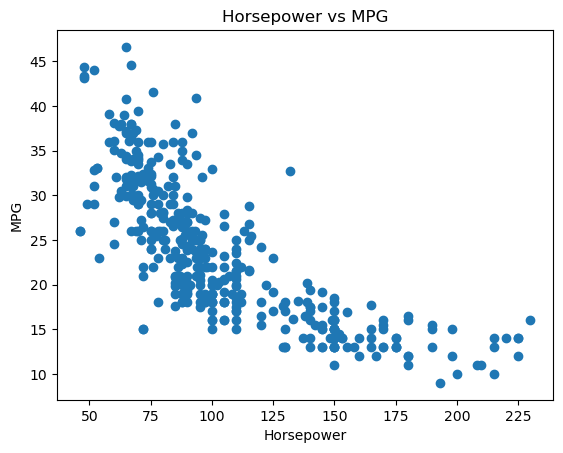

In [9]:
plt.figure()
plt.scatter(X, Y)
plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.title("Horsepower vs MPG")
plt.show()

In [10]:
#using formula
x = df['horsepower'].values
y = df['mpg'].values

x_mean = np.mean(x)
y_mean = np.mean(y)

b1 = np.sum((x - x_mean)*(y - y_mean)) / np.sum((x - x_mean)**2)
b0 = y_mean - b1 * x_mean

print("Formula Intercept:", b0)
print("Formula Slope:", b1)

Formula Intercept: 40.01131787111278
Formula Slope: -0.15816020313402757


In [11]:
#using scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression


X_train, X_test, Y_train, Y_test = train_test_split( X, Y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, Y_train)
Y_pred_sklearn = model.predict(X_test)
print("Intercept:", model.intercept_)
print("Slope:", model.coef_[0])

Intercept: 40.51716423366811
Slope: -0.16395719614905888


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


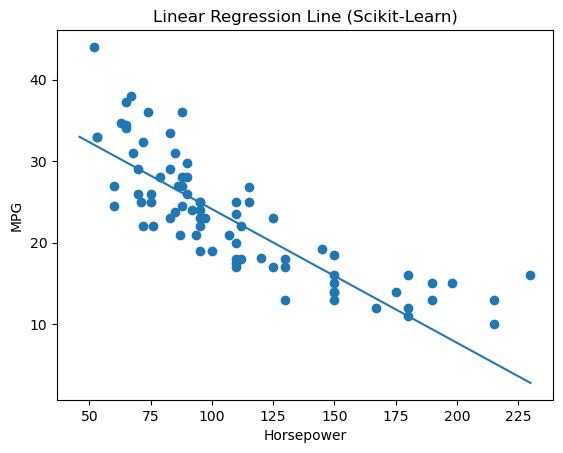

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Scatter plot of actual data
plt.figure()
plt.scatter(X_test, Y_test)

# Create smooth line values
x_line = np.linspace(X.min(), X.max(), 100).reshape(-1,1)
y_line = model.predict(x_line)

# Plot regression line
plt.plot(x_line, y_line)

plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.title("Linear Regression Line (Scikit-Learn)")
plt.show()